The dataset spans from Jan. 2 2015 to Dec.30 2025. However, to ensure the statistical integrity of the results, a 60-month (5-year) rolling estimation window was implemented. Consequently, the period from 2020 to 2026 serves as the initial training phase for the Ridge Regression and covariance estimation.

The empirical results and performance metrics reported in this study cover the period from Jan. 2020 to Dec. 2025. This ensures that all portfolio returns are strictly out-of-sample, providing a realistic representation of the model's performance in a live trading environment.

Fetching ETF market data...
Fetching FRED macroeconomic data...

Executing Parallel Backtest for all Strategies...

EMPIRICAL RESEARCH EVALUATION MATRIX
                      Equal Weight (1/N) Benchmark 1 (MVO) Benchmark 2 (Standard BL) Proposed 1 (Baseline Omega) Proposed 2 (Advanced Omega) Proposed 3 (Dynamic BL)
Annualized Return                 17.10%            40.49%                    26.51%                      18.63%                      19.27%                  20.94%
Sharpe Ratio                       1.145             1.161                     1.096                       1.160                       1.120                   1.182
Information Ratio                    N/A             0.894                     0.610                       0.289                       0.297                   0.458
Maximum Drawdown                 -20.29%           -45.25%                   -31.65%                     -23.60%                     -26.96%                 -26.28%
Annualized Volatility 

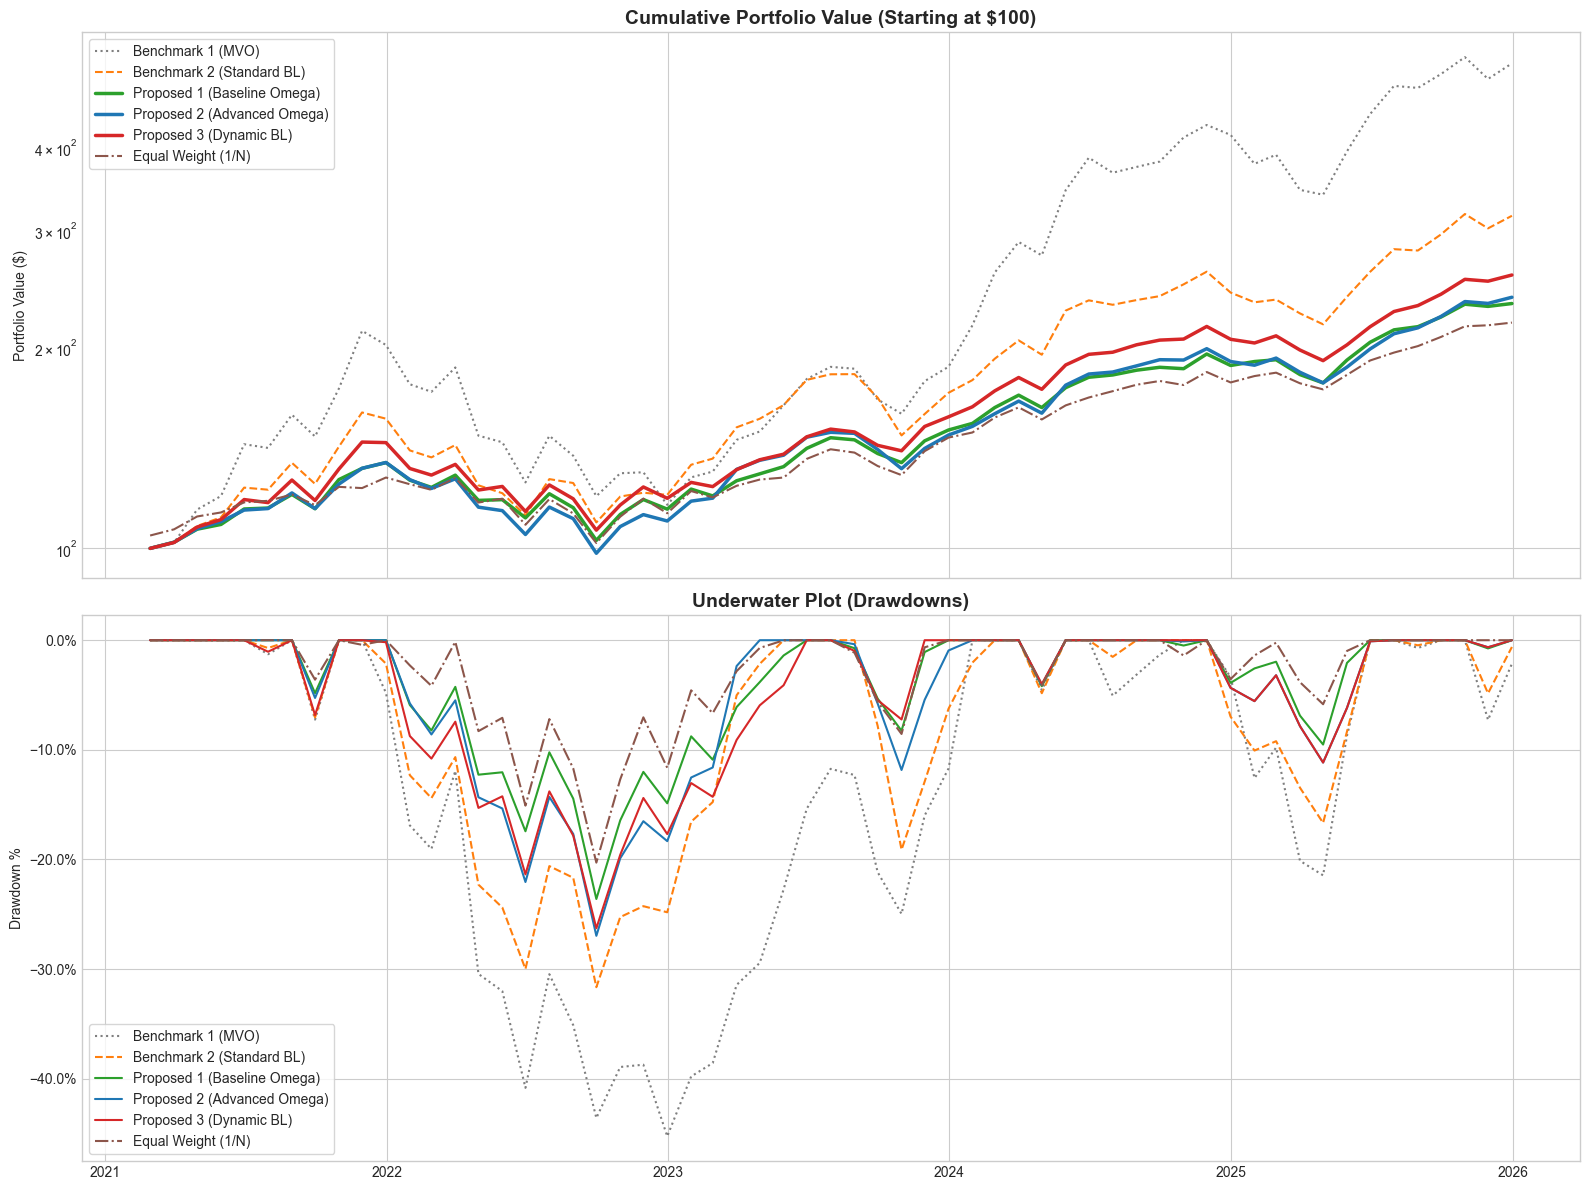

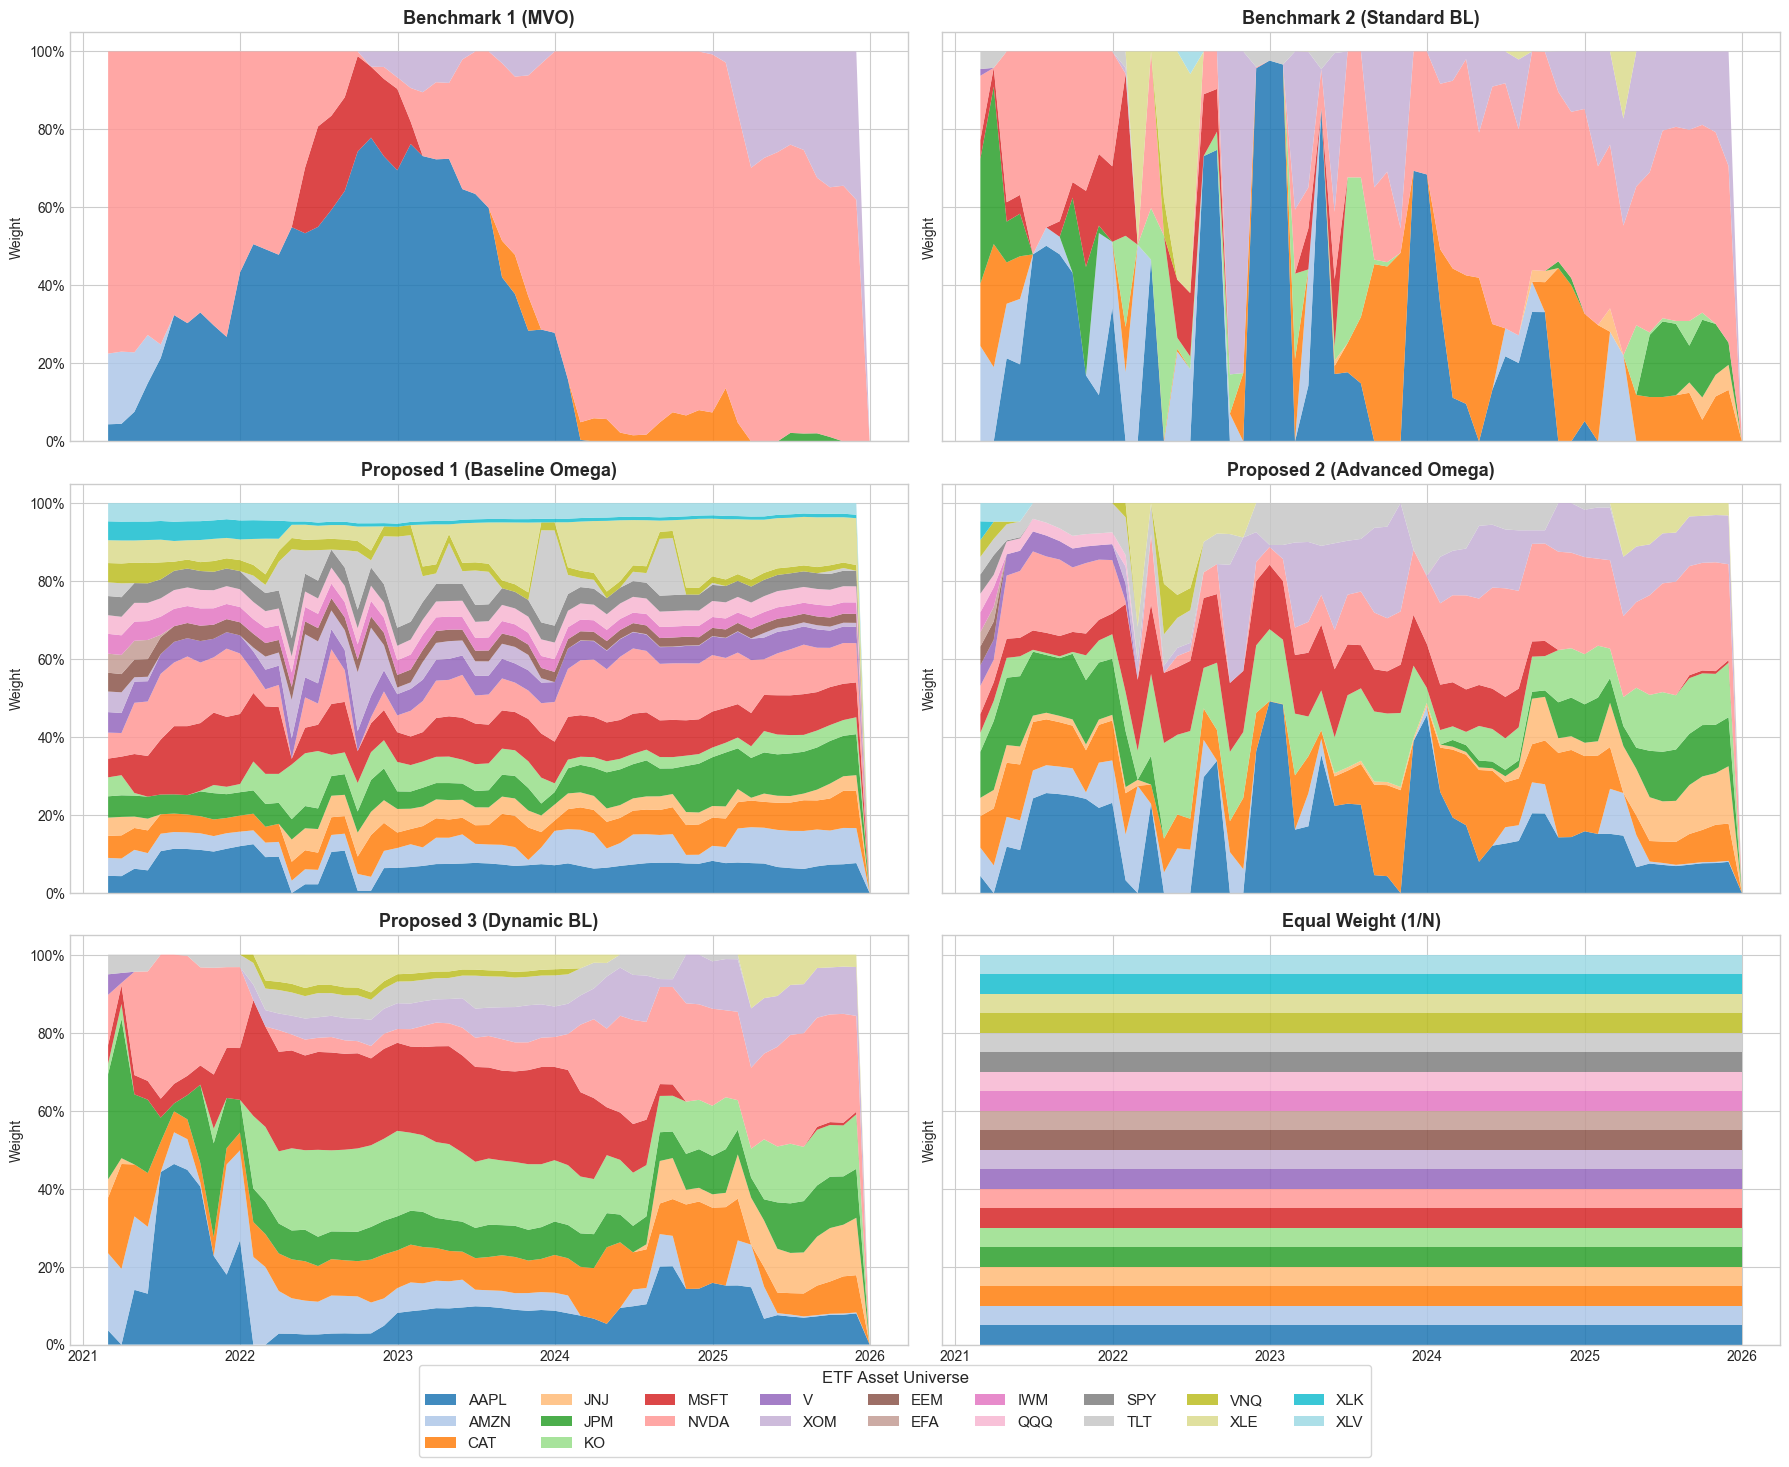

In [12]:
import numpy as np
import pandas as pd
import tabula
import cvxpy as cp
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import Ridge
from yahooquery import Ticker
import pandas_datareader.data as web
import warnings

# Suppress warnings for clean console output
warnings.filterwarnings('ignore')

# ============================================================================
# 1. DATA PIPELINE (yahooquery & FRED)
# ============================================================================

def fetch_hybrid_market_data(tickers: list, start_date: str, end_date: str):
    """Fetches ETF data and returns both Daily and Monthly returns."""
    print("Fetching ETF market data...")
    tq = Ticker(tickers)
    df = tq.history(start=start_date, end=end_date)

    daily_prices = df['adjclose'].unstack(level=0)
    daily_prices.index = pd.to_datetime(daily_prices.index)

    daily_returns = daily_prices.pct_change().dropna()
    monthly_prices = daily_prices.resample('ME').last()
    monthly_returns = monthly_prices.pct_change().dropna()

    return daily_returns, monthly_returns

def fetch_macro_factors(start_date: str, end_date: str) -> pd.DataFrame:
    """Fetches macroeconomic data from FRED and creates stationary features."""
    print("Fetching FRED macroeconomic data...")
    series_dict = {
        'INDPRO': 'Growth',
        'CPIAUCSL': 'Inflation',
        'GS10': 'Rates',
        'BAA10Y': 'Credit'
    }
    raw_df = web.DataReader(list(series_dict.keys()), 'fred', start_date, end_date)
    raw_df.rename(columns=series_dict, inplace=True)
    raw_df.index = pd.to_datetime(raw_df.index)

    monthly_macro = raw_df.resample('ME').last()

    features = pd.DataFrame(index=monthly_macro.index)
    features['Growth_Signal'] = monthly_macro['Growth'].pct_change()
    features['Inflation_Signal'] = monthly_macro['Inflation'].pct_change(periods=12)
    features['Rates_Signal'] = monthly_macro['Rates'].diff()
    features['Credit_Signal'] = monthly_macro['Credit'].diff()

    return features.dropna()

# ============================================================================
# 2. VIEW GENERATOR (Macro Regression & Data-Driven BL)
# ============================================================================

def generate_bl_views(
    y_monthly_train: np.ndarray,
    X_monthly_train: np.ndarray,
    X_current: np.ndarray,
    daily_returns_window: pd.DataFrame,
    market_weights: np.ndarray,
    risk_aversion: float = 2.5,
    tau: float = 0.05,
    omega_method: str = 'advanced',
    kappa: float = 0.25,
    ridge_alpha: float = 1.0
):
    """Generates BL posterior expected returns and covariance matrix."""
    n_assets = y_monthly_train.shape[1]

    # 1. Scaled Covariance from Daily Data
    sigma_monthly = daily_returns_window.cov().values * 21

    # 2. Prior Equilibrium (Pi)
    pi = risk_aversion * np.dot(sigma_monthly, market_weights)

    # 3. View Generation (Q)
    q_views = np.zeros(n_assets)
    residual_variances = np.zeros(n_assets)

    for i in range(n_assets):
        model = Ridge(alpha=ridge_alpha)
        model.fit(X_monthly_train, y_monthly_train[:, i])

        q_views[i] = model.predict(X_current.reshape(1, -1))[0]

        # Calculate in-sample residual variance for Baseline Omega
        residuals = y_monthly_train[:, i] - model.predict(X_monthly_train)
        residual_variances[i] = np.var(residuals, ddof=1)

    # 4. Uncertainty Matrix (Omega) Formulation
    if omega_method == 'baseline':
        # Method 1: Historical Forecast Error Variance
        omega = np.diag(residual_variances)
    elif omega_method == 'advanced':
        # Method 2: Parameterized Scaling (Regime-Aware)
        omega = kappa * sigma_monthly
    else:
        # Standard BL: Subjective heuristic
        omega = tau * sigma_monthly

    # 5. Posterior Update
    tau_sigma_inv = np.linalg.inv(tau * sigma_monthly)
    omega_inv = np.linalg.inv(omega)

    M = np.linalg.inv(tau_sigma_inv + omega_inv)

    pi_comp = np.dot(tau_sigma_inv, pi)
    view_comp = np.dot(omega_inv, q_views)

    post_returns = np.dot(M, (pi_comp + view_comp))
    post_cov = sigma_monthly + M

    return post_returns, post_cov


def select_best_kappa(t, kappa_grid, returns_history_dict, lookback_period=24):
    """
    Selects the optimal kappa by evaluating the Sharpe Ratio of different
    parameters over a specific lookback window.
    """
    best_kappa = kappa_grid[0]
    max_sharpe = -np.inf

    # Evaluate each kappa in our pre-defined grid
    for k in kappa_grid:
        # Extract the net returns for this specific kappa over the last 24 months
        # We assume these were pre-calculated or stored during the backtest
        recent_returns = returns_history_dict[k][t - lookback_period : t]

        if len(recent_returns) < lookback_period:
            continue

        # Calculate the localized Sharpe Ratio
        vol = np.std(recent_returns, ddof=1) * np.sqrt(12)
        ann_ret = np.mean(recent_returns) * 12
        sharpe = ann_ret / vol if vol > 0 else -np.inf

        if sharpe > max_sharpe:
            max_sharpe = sharpe
            best_kappa = k

    return best_kappa

# ============================================================================
# 3. CORE OPTIMIZER (CVXPY)
# ============================================================================

def optimize_portfolio(expected_returns, cov_matrix, drift_weights, risk_aversion=2.5, tc_penalty=0.001):
    """Mean-Variance Optimization with L1-Norm Turnover Penalty."""
    n_assets = len(expected_returns)
    w = cp.Variable(n_assets)

    ret = expected_returns.T @ w
    vol = cp.quad_form(w, cov_matrix)
    utility = ret - (risk_aversion / 2) * vol

    if drift_weights is not None:
        utility -= tc_penalty * cp.norm(w - drift_weights, 1)

    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(cp.Maximize(utility), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True)

    weights = w.value
    weights = np.where(weights < 1e-5, 0, weights)
    return weights / np.sum(weights)

# ============================================================================
# 4. EVALUATION & REPORTING
# ============================================================================

def calculate_portfolio_metrics(strategy_returns, benchmark_returns=None, turnover_history=None):
    metrics = {}
    ann_return = np.mean(strategy_returns) * 12
    ann_vol = np.std(strategy_returns, ddof=1) * np.sqrt(12)

    metrics['Annualized Return'] = ann_return
    metrics['Annualized Volatility'] = ann_vol
    metrics['Sharpe Ratio'] = ann_return / ann_vol if ann_vol != 0 else np.nan

    if benchmark_returns is not None:
        active_returns = strategy_returns - benchmark_returns
        ann_active_return = np.mean(active_returns) * 12
        tracking_error = np.std(active_returns, ddof=1) * np.sqrt(12)
        metrics['Information Ratio'] = ann_active_return / tracking_error if tracking_error != 0 else np.nan
    else:
        metrics['Information Ratio'] = np.nan

    cum_returns = (1 + strategy_returns).cumprod()
    rolling_max = cum_returns.cummax()
    metrics['Maximum Drawdown'] = np.min((cum_returns / rolling_max) - 1)
    metrics['Value at Risk (95%)'] = np.percentile(strategy_returns, 5)

    if turnover_history is not None:
        metrics['Annualized Turnover'] = (np.mean(turnover_history) * 12) / 2
    else:
        metrics['Annualized Turnover'] = np.nan

    return metrics

def plot_comparison(returns_dict):
    """Plots cumulative returns (starting at $100) and drawdowns for all 5 strategies."""
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    colors = {
        'Equal Weight (1/N)': '#8c564b',
        'Benchmark 1 (MVO)': '#7f7f7f',
        'Benchmark 2 (Standard BL)': '#ff7f0e',
        'Proposed 1 (Baseline Omega)': '#2ca02c',
        'Proposed 2 (Advanced Omega)': '#1f77b4',
        'Proposed 3 (Dynamic BL)': '#d62728'  # New Red color for the champion model
    }
    styles = {
        'Equal Weight (1/N)': '-.',
        'Benchmark 1 (MVO)': ':',
        'Benchmark 2 (Standard BL)': '--',
        'Proposed 1 (Baseline Omega)': '-',
        'Proposed 2 (Advanced Omega)': '-',
        'Proposed 3 (Dynamic BL)': '-'
    }

    for name, rets in returns_dict.items():
        cum_ret = 100 * (1 + rets).cumprod()
        # [FIXED LINE] Uses the updated colors/styles dictionaries
        ax1.plot(cum_ret.index, cum_ret, label=name, color=colors[name],
                 linestyle=styles[name], linewidth=2.5 if 'Proposed' in name else 1.5)

        drawdown = (cum_ret / cum_ret.cummax()) - 1
        ax2.plot(drawdown.index, drawdown, label=name, color=colors[name],
                 linestyle=styles[name], linewidth=1.5)

    ax1.set_title('Cumulative Portfolio Value (Starting at $100)', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.set_ylabel('Portfolio Value ($)')
    # [FIX] Force legend to show and place it clearly
    ax1.legend(loc='upper left', frameon=True, fontsize=10)

    ax2.set_title('Underwater Plot (Drawdowns)', fontsize=14, fontweight='bold')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_ylabel('Drawdown %')
    ax2.legend(loc='lower left', frameon=True, fontsize=10)

    plt.tight_layout()


def plot_asset_allocation(weights_dict):
    """
    Plots a grid of stacked area charts for all strategies.
    Adjusted to a 3x2 grid to accommodate 5 strategies.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    # Changed grid to 3 rows, 2 columns to fit 5 strategies
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True, sharey=True)
    axes = axes.flatten()

    # Use tab20 to support your 20 assets with distinct colors
    colors_palette = plt.cm.tab20.colors
    strategy_names = list(weights_dict.keys())

    for idx in range(len(axes)):
        ax = axes[idx]
        if idx < len(strategy_names):
            name = strategy_names[idx]
            weights_df = weights_dict[name]
            ax.stackplot(weights_df.index, weights_df.T, labels=weights_df.columns,
                         colors=colors_palette, alpha=0.85)
            ax.set_title(name, fontsize=13, fontweight='bold')
            ax.set_ylabel('Weight')
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        else:
            # Hide empty subplots if any
            ax.axis('off')

    # Shared Legend at the bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=9, bbox_to_anchor=(0.5, 0.02),
               title='ETF Asset Universe', title_fontsize=12, fontsize=11, frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1) # Make room for the legend

# ============================================================================
# 5. MAIN BACKTEST ENGINE
# ============================================================================

def run_empirical_study():
    """
    Main engine to run the empirical backtest for all strategies.
    Fixes: Added kappa_grid, synchronized Dynamic BL settlement.
    """
    # 1. Define Asset Universe and Time Horizon
    assets = [ 'AAPL', 'AMZN', 'CAT', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'V', 'XOM', 'EEM', 'EFA', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ', 'XLE', 'XLK', 'XLV']
    start_date = '2015-01-02'
    end_date = '2025-12-30'

    # Define kappa_grid inside the function
    kappa_grid = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5]

    # 2. Fetch Market and Macroeconomic Data
    daily_rets, monthly_rets = fetch_hybrid_market_data(assets, start_date, end_date)
    macro_df = fetch_macro_factors(start_date, end_date)

    common_idx = monthly_rets.index.intersection(macro_df.index)
    monthly_rets = monthly_rets.loc[common_idx]
    macro_df = macro_df.loc[common_idx]

    # 3. Backtest Parameters
    window_months = 60
    tc_rate = 0.001
    n_months, n_assets = monthly_rets.shape

    strategies = [
        'Benchmark 1 (MVO)',
        'Benchmark 2 (Standard BL)',
        'Proposed 1 (Baseline Omega)',
        'Proposed 2 (Advanced Omega)',
        'Proposed 3 (Dynamic BL)'
    ]

    # Initialize tracking
    grid_returns_track = {k: np.zeros(n_months) for k in kappa_grid}
    current_weights = {s: np.ones(n_assets) / n_assets for s in strategies}
    net_returns_hist = {s: np.zeros(n_months) for s in strategies}
    turnover_hist = {s: np.zeros(n_months) for s in strategies}
    weights_hist = {s: np.zeros((n_months, n_assets)) for s in strategies}

    # Initialize current_best_kappa
    current_best_kappa = 0.25

    print("\nExecuting Parallel Backtest for all Strategies...")

    # 4. Rolling Out-of-Sample Backtest Loop
    for t in range(window_months, n_months - 1):
        y_train_m = monthly_rets.iloc[t - window_months + 1 : t + 1].values
        X_train_m = macro_df.iloc[t - window_months : t].values
        X_curr_m = macro_df.iloc[t].values

        start_period = monthly_rets.index[t - window_months + 1]
        end_period = monthly_rets.index[t]
        daily_window = daily_rets.loc[start_period:end_period]
        sigma_monthly = daily_window.cov().values * 21
        ret_t = monthly_rets.iloc[t].values

        # --- A. Grid Search for Kappa (Internal Tracking) ---
        for k in kappa_grid:
            e_ret_k, cov_k = generate_bl_views(y_train_m, X_train_m, X_curr_m, daily_window,
                                              np.ones(n_assets)/n_assets, omega_method='advanced', kappa=k)
            w_k = optimize_portfolio(e_ret_k, cov_k, None)
            grid_returns_track[k][t+1] = np.dot(w_k, monthly_rets.iloc[t+1].values)

        if t % 12 == 0:
            current_best_kappa = select_best_kappa(t, kappa_grid, grid_returns_track, lookback_period=24)

        # --- B. Prepare Optimization Inputs for ALL strategies ---
        opt_inputs = {}

        # 1. Benchmark 1
        d_w1 = (current_weights['Benchmark 1 (MVO)'] * (1 + ret_t))
        opt_inputs['Benchmark 1 (MVO)'] = (np.mean(y_train_m, axis=0), sigma_monthly, d_w1 / np.sum(d_w1))

        # 2. Benchmark 2
        d_w2 = (current_weights['Benchmark 2 (Standard BL)'] * (1 + ret_t))
        e2, c2 = generate_bl_views(y_train_m, X_train_m, X_curr_m, daily_window, np.ones(n_assets)/n_assets, omega_method='subjective')
        opt_inputs['Benchmark 2 (Standard BL)'] = (e2, c2, d_w2 / np.sum(d_w2))

        # 3. Proposed 1
        d_w3 = (current_weights['Proposed 1 (Baseline Omega)'] * (1 + ret_t))
        e3, c3 = generate_bl_views(y_train_m, X_train_m, X_curr_m, daily_window, np.ones(n_assets)/n_assets, omega_method='baseline')
        opt_inputs['Proposed 1 (Baseline Omega)'] = (e3, c3, d_w3 / np.sum(d_w3))

        # 4. Proposed 2
        d_w4 = (current_weights['Proposed 2 (Advanced Omega)'] * (1 + ret_t))
        e4, c4 = generate_bl_views(y_train_m, X_train_m, X_curr_m, daily_window, np.ones(n_assets)/n_assets, omega_method='advanced', kappa=0.25)
        opt_inputs['Proposed 2 (Advanced Omega)'] = (e4, c4, d_w4 / np.sum(d_w4))

        # Add Proposed 3 to opt_inputs so it gets settled in the loop
        d_w5 = (current_weights['Proposed 3 (Dynamic BL)'] * (1 + ret_t))
        e5, c5 = generate_bl_views(y_train_m, X_train_m, X_curr_m, daily_window, np.ones(n_assets)/n_assets, omega_method='advanced', kappa=current_best_kappa)
        opt_inputs['Proposed 3 (Dynamic BL)'] = (e5, c5, d_w5 / np.sum(d_w5))

        # --- C. Settlement for t+1 ---
        ret_t_plus_1 = monthly_rets.iloc[t+1].values

        for name, (e_ret, cov_mat, d_w) in opt_inputs.items():
            new_w = optimize_portfolio(e_ret, cov_mat, d_w, tc_penalty=tc_rate)

            # Record turnover based on drifted weights
            turnover = np.sum(np.abs(new_w - d_w))
            tc = turnover * tc_rate

            # Portfolio return calculation
            gross_ret = np.dot(current_weights[name], ret_t_plus_1)
            net_returns_hist[name][t+1] = gross_ret - tc
            turnover_hist[name][t] = turnover
            weights_hist[name][t] = new_w
            current_weights[name] = new_w

   # ============================================================================
    # 5. Compilation & Evaluation
    # ============================================================================
    eval_idx = monthly_rets.index[window_months:]
    series_returns = {name: pd.Series(net_returns_hist[name][window_months:], index=eval_idx) for name in strategies}
    series_turnovers = {name: pd.Series(turnover_hist[name][window_months:], index=eval_idx) for name in strategies}
    series_weights = {name: pd.DataFrame(weights_hist[name][window_months:], index=eval_idx, columns=assets) for name in strategies}

    # --- [NEW: Construct Equal Weight (1/N) Portfolio] ---
    # Calculate returns (average of all assets each month)
    ew_returns_oos = monthly_rets.loc[eval_idx].mean(axis=1)

    # Create constant 1/N weights for plotting
    ew_weights_oos = pd.DataFrame(1 / n_assets, index=eval_idx, columns=assets)

    # Add to our tracking dictionaries
    passive_name = 'Equal Weight (1/N)'
    series_returns[passive_name] = ew_returns_oos
    series_weights[passive_name] = ew_weights_oos

    # For a naive 1/N, we assume 0 turnover for reporting simplicity
    series_turnovers[passive_name] = pd.Series(0.0, index=eval_idx)

    # --- [Evaluate All Strategies] ---
    report = {}
    # We iterate over all 6 strategies now
    for name, rets in series_returns.items():
        # Everyone uses the Equal Weight portfolio as the benchmark for the Information Ratio
        report[name] = calculate_portfolio_metrics(
            rets,
            benchmark_returns=ew_returns_oos,
            turnover_history=series_turnovers[name]
        )

    # Order the columns so the passive benchmark is first
    ordered_columns = [passive_name] + strategies

    report_df = pd.DataFrame(report).reindex([
        'Annualized Return', 'Sharpe Ratio', 'Information Ratio',
        'Maximum Drawdown', 'Annualized Volatility', 'Value at Risk (95%)', 'Annualized Turnover'
    ])[ordered_columns] # Reorder columns for clean presentation

    # 6. Formatting & Output
    fmt_df = report_df.copy()
    for col in ['Annualized Return', 'Maximum Drawdown', 'Annualized Volatility', 'Value at Risk (95%)', 'Annualized Turnover']:
        fmt_df.loc[col] = fmt_df.loc[col].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
    for col in ['Sharpe Ratio', 'Information Ratio']:
        fmt_df.loc[col] = fmt_df.loc[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

    print("\n" + "="*90)
    print("EMPIRICAL RESEARCH EVALUATION MATRIX")
    print("="*90)
    print(fmt_df.to_string())

   # ==========================================
    # 7. Export & Plot
    # ==========================================
    result_dir = os.path.join(os.getcwd(), 'result')
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    # 1. Export Excel Metrics
    excel_path = os.path.join(result_dir, "empirical_evaluation_metrics.xlsx")
    report_df.to_excel(excel_path, index=True)
    print(f"[Success] Metrics saved to {excel_path}")

    # 2. Plot & Save Cumulative Returns
    plot_comparison(series_returns) # This function creates the first figure
    plt.savefig(os.path.join(result_dir, "return_comparison.pdf"), bbox_inches='tight', dpi=300)
    print("[Success] Return plot saved as PDF.")

    # 3. Plot & Save Asset Allocation
    plot_asset_allocation(series_weights) # This function creates the second figure
    plt.savefig(os.path.join(result_dir, "weights_comparison.pdf"), bbox_inches='tight', dpi=300)
    print("[Success] Weights plot saved as PDF.")

    # 4. Finally, show them on screen
    plt.show()

if __name__ == "__main__":
    run_empirical_study()
